## 2025 빅콘테스트 AI 데이터 경진대회
팀 DA4U (송휘린, 강예서, 김서정, 문찬우) \
마감일: 10월 24일 (금)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
pd.set_option('display.max_columns', None)

In [22]:
df1 = pd.read_csv("dataset/big_data_set1_f.csv", encoding="cp949")
df2 = pd.read_csv("dataset/big_data_set2_f.csv", encoding="cp949")
df3 = pd.read_csv("dataset/big_data_set3_f.csv", encoding="cp949")

In [23]:
print("df1:", df1.shape)
print("df2:", df2.shape)
print("df3:", df3.shape)

df1: (4185, 9)
df2: (86590, 15)
df3: (86590, 17)


In [24]:
print("\n컬럼명:", df1.columns.tolist())
# 결측치 요약
print("\n결측치 개수:\n", df1.isna().sum())

# 기본 통계
print("\n기본 통계:\n", df1.describe(include="all"))


컬럼명: ['ENCODED_MCT', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM', 'HPSN_MCT_BZN_CD_NM', 'ARE_D', 'MCT_ME_D']

결측치 개수:
 ENCODED_MCT              0
MCT_BSE_AR               0
MCT_NM                   0
MCT_BRD_NUM           3643
MCT_SIGUNGU_NM           0
HPSN_MCT_ZCD_NM          0
HPSN_MCT_BZN_CD_NM    1047
ARE_D                    0
MCT_ME_D              4058
dtype: int64

기본 통계:
        ENCODED_MCT          MCT_BSE_AR MCT_NM MCT_BRD_NUM MCT_SIGUNGU_NM  \
count         4185                4185   4185         542           4185   
unique        4185                2938   3386         287              1   
top     16184E93D9  서울특별시 성동구 왕십리로 410   성수**      커피전문점2         서울 성동구   
freq             1                  73     31          20           4185   
mean           NaN                 NaN    NaN         NaN            NaN   
std            NaN                 NaN    NaN         NaN            NaN   
min            NaN                 NaN    NaN       

## 칼럼명 쉽게 수정 

In [25]:
df1.columns = [
    "코드",
    "기준면적",
    "가맹점명",
    "브랜드코드",
    "지역",
    "업종",
    "상권",
    "개설일",
    "폐업일"
]

df2.columns = [
    "코드",
    "기준년월",
    "운영개월수",
    "매출금액",
    "매출건수",
    "유니크고객수",
    "객단가",
    "취소율",
    "배달매출비율",
    "동종매출금액%",
    "동종매출건수%",
    "동종매출순위%",
    "동일상권매출순위%",
    "동종해지가맹점%",
    "동일상권해지가맹점비중"
]

df3.columns = [
    "코드",
    "기준년월",
    "남20대이하",
    "남30대",
    "남40대",
    "남50대",
    "남60대이상",
    "여20대이하",
    "여30대",
    "여40대",
    "여50대",
    "여60대이상",
    "재방문고객",
    "신규고객",
    "거주이용고객",
    "직장이용고객",
    "유동인구이용고객"
]

In [26]:
print(df1.head())
print(df2.head())  
print(df3.head())

           코드        기준면적  가맹점명 브랜드코드      지역   업종   상권       개설일  폐업일
0  16184E93D9  서울 성동구 마장동  성우**   NaN  서울 성동구  축산물  마장동  20130320  NaN
1  4D039EA8B7  서울 성동구 마장동  대보**   NaN  서울 성동구  축산물  마장동  20131122  NaN
2  0074C4990A  서울 성동구 마장동  대용**   NaN  서울 성동구  축산물  마장동  20140512  NaN
3  68308F2746  서울 성동구 마장동  통일**   NaN  서울 성동구  축산물  마장동  20151124  NaN
4  4117EDDE9C  서울 성동구 마장동  한울**   NaN  서울 성동구  축산물  마장동  20151211  NaN
           코드    기준년월     운영개월수                매출금액                매출건수  \
0  000F03E44A  202404  4_50-75%            5_75-90%            5_75-90%   
1  000F03E44A  202312  4_50-75%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
2  002816BA73  202404  2_10-25%            3_25-50%            4_50-75%   
3  002816BA73  202411  2_10-25%            3_25-50%            4_50-75%   
4  002816BA73  202406  2_10-25%            4_50-75%            4_50-75%   

               유니크고객수                 객단가             취소율    배달매출비율  동종매출금액%  \
0            5_75-90%            5_75-90%  

## DF 병합 

In [27]:
# df2와 df3를 (가맹점코드, 기준년월)로 병합
#   - 교집합만 원하면 how="inner", 한쪽에만 있는 월도 살리고 싶으면 how="outer"
df23 = pd.merge(
    df2, df3,
    on=["코드", "기준년월"],
    how="outer",
    suffixes=("_x", "_y")
)

print(df23.head())

           코드    기준년월     운영개월수                매출금액                매출건수  \
0  000F03E44A  202301  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   
1  000F03E44A  202302  5_75-90%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
2  000F03E44A  202303  5_75-90%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
3  000F03E44A  202304  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   
4  000F03E44A  202305  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   

               유니크고객수                 객단가      취소율    배달매출비율  동종매출금액%  \
0            5_75-90%            4_50-75%  1_상위1구간 -999999.9      0.5   
1  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)      NaN -999999.9      0.0   
2  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)      NaN -999999.9      0.0   
3            5_75-90%            3_25-50%  1_상위1구간 -999999.9      1.3   
4            5_75-90%  6_90%초과(하위 10% 이하)  1_상위1구간 -999999.9      0.0   

   동종매출건수%  동종매출순위%  동일상권매출순위%  동종해지가맹점%  동일상권해지가맹점비중  남20대이하     남30대  남40대  \
0      1.1     95.3       75.1

In [28]:
# 0) 키 타입 맞추기(중요)
df23['코드'] = df23['코드'].astype(str)
df1['코드']  = df1['코드'].astype(str)

# 1) df1에서 코드가 중복이라면 먼저 정리
df1_u = df1.sort_values(['코드','폐업일','개설일']).drop_duplicates('코드', keep='last')

df = df1.merge(df23, on="코드", how="right", validate="1:m")



## 전처리 

In [29]:
# 백분율 구간 치환 
mapping = {'1_10%이하':'10%', '2_10-25%':'25%','3_25-50%':'50%','4_50-75%':'75%','5_75-90%':'90%',   
       '6_90%초과(하위 10% 이하)':'100%',  }
       
cols = ['운영개월수', '매출금액', '매출건수', '유니크고객수', '객단가']

for c in cols:
    df[c] = df[c].map(mapping).fillna(df[c])


In [30]:
mapping2 = {
    '1_상위1구간': '상위1',
    '2_상위2구간': '상위2',
    '3_상위3구간': '상위3',
    '4_상위4구간': '상위4',
    '5_상위5구간': '상위5',
    '6_상위6구간(하위1구간)': '상위6'
}

df['취소율'] = df['취소율'].replace(mapping2)


In [31]:
import numpy as np
df = df.replace(-999999.9, np.nan)

#지역이 성동구가 아닌 점포 제외 
df['상권'] = df['상권'].fillna('미표기')
df = df.groupby('상권').filter(lambda g: g['코드'].nunique() >= 3).copy()

In [32]:
df['상권'].unique()

array(['뚝섬', '마장동', '답십리', '성수', '미표기', '왕십리', '금남시장', '한양대', '장한평자동차',
       '옥수', '신금호', '행당'], dtype=object)

In [33]:
df['업종'].unique()

array(['중식-딤섬/중식만두', '요리주점', '백반/가정식', '커피전문점', '한식-찌개/전골', '룸살롱/단란주점',
       '한식-냉면', '축산물', '한식-단품요리일반', '양식', '일반 유흥주점', '한식-해물/생선', '포장마차',
       '청과물', '카페', '한식-육류/고기', '베이커리', '식료품', '중식당', '호프/맥주', '한식-국수/만두',
       '햄버거', '샌드위치/토스트', '치킨', '동남아/인도음식', '이자카야', '한식-국밥/설렁탕', '일식당',
       '피자', '인삼제품', '떡/한과 제조', '분식', '주류', '꼬치구이', '중식-훠궈/마라탕',
       '일식-우동/소바/라면', '와인바', '수산물', '한식뷔페', '농산물', '아이스크림/빙수', '민속주점',
       '건강원', '일식-덮밥/돈가스', '담배', '한식-감자탕', '식품 제조', '차', '건강식품', '기타세계요리',
       '일식-초밥/롤', '반찬', '도시락', '한정식', '일식-샤브샤브', '와인샵', '미곡상', '마카롱',
       '탕후루', '일식-참치회', '기사식당', '도너츠', '주스', '떡/한과', '구내식당/푸드코트',
       '테이크아웃커피', '한식-죽', '유제품', '테마카페', '건어물', '한식-두부요리', '와플/크로플',
       '스테이크'], dtype=object)

## 간단한 분석 

In [34]:
# 윈도우: 맑은 고딕으로 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [15]:
col = "동종매출건수%"

# 숫자형 변환 (혹시 문자열 섞였을 때 대비)
df[col] = pd.to_numeric(df[col], errors='coerce')

# 이상치 행 전체 추출
outliers = df[df[col] > 2000]

print("이상치 행 개수:", len(outliers))
display(outliers.head(10))   # Jupyter이면 display(), 콘솔이면 print()




이상치 행 개수: 91


,코드,기준면적,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,기준년월,운영개월수,매출금액,매출건수,유니크고객수,객단가,취소율,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객
1294,02FE4FD151,서울특별시 성동구 왕십리로4길 28-2,로우*****,NaN,서울 성동구,커피전문점,뚝섬,20180814,NaN,202404,50%,10%,10%,10%,90%,상위2,NaN,360.7,2109.6,5.1,9.4,17.5,7.8,13.0385,19.4020,7.9210,3.1595,0.9790,16.2615,24.1980,9.8790,3.9405,1.2210,36.97,10.90,16.8,25.1,58.1
4304,0C25C3B746,서울특별시 성동구 아차산로 113,성수*******,샌드위치/토스트2,서울 성동구,샌드위치/토스트,성수,20230130,NaN,202404,90%,10%,10%,10%,75%,상위5,18.9,738.1,2008.9,0.9,2.2,17.5,8.0,18.8325,15.9960,5.1615,4.5570,1.9995,21.6675,18.4040,5.9385,5.2430,2.3005,32.06,8.32,20.0,22.5,57.5
6914,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202301,50%,10%,10%,10%,90%,상위2,NaN,354.7,3460.7,4.3,7.1,19.8,8.0,13.4620,13.6144,11.2776,8.7884,3.6576,13.0380,13.1856,10.9224,8.5116,3.5424,35.44,6.70,16.1,26.6,57.3
6915,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202302,50%,10%,10%,10%,90%,상위3,NaN,383.9,3417.9,4.3,7.0,20.2,7.9,13.1805,13.6350,11.3120,8.7365,3.6865,12.9195,13.3650,11.0880,8.5635,3.6135,35.11,7.35,15.1,26.4,58.5
6916,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202303,50%,10%,10%,10%,90%,상위2,NaN,376.4,3333.3,4.2,7.1,21.1,8.6,12.8500,13.6500,11.1500,8.7500,3.6500,12.8500,13.6500,11.1500,8.7500,3.6500,35.29,7.28,14.5,26.2,59.4
6917,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202304,50%,10%,10%,10%,90%,상위3,NaN,382.0,3465.0,4.0,6.8,21.9,9.0,12.7710,13.5630,10.8405,8.6625,3.6630,13.0290,13.8370,11.0595,8.8375,3.7370,35.13,7.69,14.1,27.5,58.4
6918,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202305,50%,25%,10%,10%,90%,상위2,NaN,274.1,2595.0,4.0,6.7,22.7,8.8,12.6936,13.5300,10.6764,8.6592,3.6408,13.1064,13.9700,11.0236,8.9408,3.7592,34.69,5.91,14.9,24.1,61.0
6919,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202306,50%,25%,10%,10%,90%,상위2,NaN,288.2,2717.0,3.9,6.7,22.3,8.7,12.5874,13.4136,10.4976,8.5536,3.5478,13.3126,14.1864,11.1024,9.0464,3.7522,34.40,5.72,15.2,26.0,58.8
6920,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202307,50%,25%,10%,10%,90%,상위2,NaN,267.4,2687.1,3.9,6.7,21.7,8.7,12.5280,13.2480,10.2720,8.4480,3.5040,13.5720,14.3520,11.1280,9.1520,3.7960,34.27,6.21,15.0,24.1,60.9
6921,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,202308,50%,25%,10%,10%,90%,상위2,NaN,244.2,2314.5,3.9,6.6,21.2,8.9,12.5236,13.2406,10.1336,8.4606,3.4416,13.6764,14.4594,11.0664,9.2394,3.7584,34.46,5.08,15.7,25.8,58.5


In [16]:
print(df.head())
df

           코드                 기준면적  가맹점명 브랜드코드      지역          업종  상권  \
0  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
1  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
2  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
3  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
4  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   

        개설일  폐업일    기준년월 운영개월수  매출금액  매출건수 유니크고객수   객단가  취소율  배달매출비율  동종매출금액%  \
0  20220225  NaN  202301   90%  100%   90%    90%   75%  상위1     NaN      0.5   
1  20220225  NaN  202302   90%  100%  100%   100%  100%  NaN     NaN      0.0   
2  20220225  NaN  202303   90%  100%  100%   100%  100%  NaN     NaN      0.0   
3  20220225  NaN  202304   90%  100%   90%    90%   50%  상위1     NaN      1.3   
4  20220225  NaN  202305   90%  100%   90%    90%  100%  상위1     NaN      0.0   

   동종매출건수%  동종매출순위%  동일상권매출순위%  동종해지가맹점%  동일상권해지가맹점비중  남20대이하     남3

,코드,기준면적,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,기준년월,운영개월수,매출금액,매출건수,유니크고객수,객단가,취소율,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객
0,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,202301,90%,100%,90%,90%,75%,상위1,NaN,0.5,1.1,95.3,75.1,15.8,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,100.00,0.0,0.0,100.0
1,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,202302,90%,100%,100%,100%,100%,NaN,NaN,0.0,0.0,95.2,75.2,16.3,8.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,NaN,NaN,NaN
2,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,202303,90%,100%,100%,100%,100%,NaN,NaN,0.0,0.0,95.0,75.2,16.7,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,NaN,NaN,NaN
3,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,202304,90%,100%,90%,90%,50%,상위1,NaN,1.3,1.0,94.5,74.3,17.3,8.2,0.0000,36.0000,0.0000,36.0000,0.0000,0.0000,14.0000,0.0000,14.0000,0.0000,0.00,50.00,0.0,100.0,0.0
4,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,202305,90%,100%,90%,90%,100%,상위1,NaN,0.0,1.0,94.6,74.5,17.9,8.0,0.0000,47.1569,0.0000,23.5431,0.0000,0.0000,19.5431,0.0000,9.7569,0.0000,0.00,33.33,0.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86585,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,202408,50%,25%,50%,50%,50%,상위1,NaN,294.8,361.7,2.8,7.6,16.6,8.0,22.0955,20.0625,6.4200,3.7450,1.2305,19.2045,17.4375,5.5800,3.2550,1.0695,9.60,6.24,16.0,20.8,63.2
86586,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,202409,50%,10%,50%,25%,25%,상위5,NaN,424.3,456.2,2.7,7.3,16.9,8.3,22.1400,20.4660,6.3180,3.9420,1.1880,18.8600,17.4340,5.3820,3.3580,1.0120,9.62,8.07,21.5,16.2,62.3
86587,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,202410,50%,25%,50%,25%,50%,상위1,NaN,333.6,386.6,2.7,7.3,16.9,8.1,21.4799,20.6804,6.0762,3.8376,1.2259,18.8201,18.1196,5.3238,3.3624,1.0741,10.27,7.48,16.8,16.0,67.2
86588,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,202411,50%,25%,50%,25%,25%,상위1,NaN,355.0,407.1,2.7,7.3,16.6,8.2,21.2464,21.2464,6.2872,4.0650,1.3550,17.9536,17.9536,5.3128,3.4350,1.1450,10.28,7.96,17.9,19.5,62.6


In [17]:
df.describe()

,개설일,폐업일,기준년월,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객
count,8.638300e+04,2.334000e+03,86383.000000,29149.000000,86383.000000,86383.000000,86383.000000,86383.000000,86383.000000,64964.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84389.000000,84750.000000,84750.000000,79085.000000,79085.000000,79085.000000
mean,2.017482e+07,2.024871e+07,202360.696734,27.658781,134.705645,152.355519,31.130645,24.013543,16.188346,8.519443,11.525444,13.370514,10.084567,11.081094,9.013418,10.865293,11.293802,7.853705,8.053693,6.859383,25.360583,9.825224,34.949238,13.191711,51.860451
std,5.726196e+04,4.974240e+03,49.949172,30.394573,168.078553,226.822725,25.231300,22.815740,3.877254,1.342184,9.934248,8.593732,7.890819,9.855032,11.575288,11.304192,8.496377,6.822567,7.357173,10.889454,15.124102,14.365952,24.616487,14.127272,23.835637
min,1.990023e+07,2.023010e+07,202301.000000,0.000000,-70.000000,0.000000,0.100000,0.000000,0.000000,4.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.015022e+07,2.025070e+07,202307.000000,3.200000,25.400000,22.200000,9.900000,1.200000,14.100000,7.900000,4.132200,7.920000,5.216400,4.740000,1.614600,2.505000,5.529000,4.377800,4.271600,1.461500,14.440000,5.100000,14.300000,3.400000,35.300000
50%,2.019091e+07,2.025072e+07,202401.000000,14.700000,82.800000,81.900000,23.800000,18.800000,17.000000,8.600000,9.883500,12.500000,9.443000,9.000000,5.054200,7.050000,9.877000,6.786000,6.700900,3.502000,24.430000,6.760000,31.600000,8.600000,50.000000
75%,2.022042e+07,2.025080e+07,202407.000000,45.000000,181.900000,199.700000,48.100000,39.100000,18.700000,9.300000,16.052700,18.152500,13.406400,15.118200,12.316500,15.554000,15.913700,9.823700,10.212400,7.611200,33.990000,8.850000,51.700000,18.800000,67.300000
max,2.024122e+07,2.025082e+07,202412.000000,111.200000,4300.900000,7059.800000,100.000000,99.600000,59.100000,12.100000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


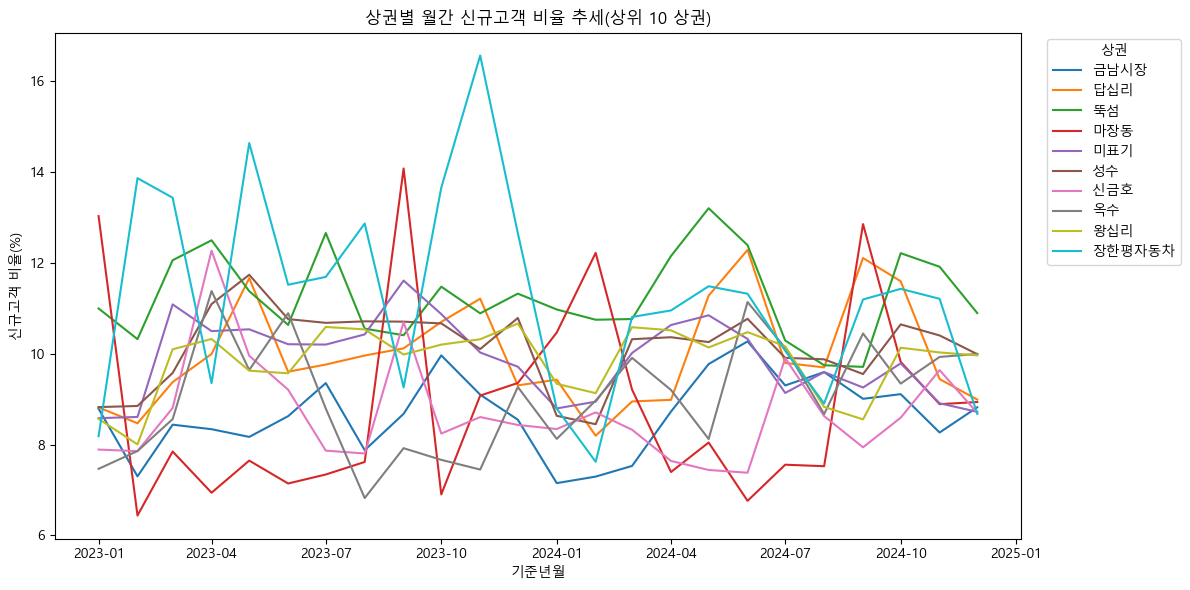

In [18]:
# 상권별 시간에 따른 신규고객 비율 라인 차트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 기준년월 시계열 컬럼 확보
if '기준년월_dt' not in df.columns:
    # df['기준년월']가 정수/문자 혼재 가능성 대비
    ym = df['기준년월'].astype(str).str.replace('-', '').str.replace('/', '').str[:6]
    df['기준년월_dt'] = pd.to_datetime(ym + '01', format='%Y%m%d', errors='coerce')

# 2) 신규고객 정제: 숫자화, 범위 클리핑(0~100), 결측 처리
new_col = '신규고객'
df[new_col] = pd.to_numeric(df[new_col], errors='coerce')
df.loc[(df[new_col] < 0) | (df[new_col] > 100), new_col] = np.nan

# 3) 상권-월별 평균 신규고객 비율 집계
agg = (
    df.dropna(subset=['상권', '기준년월_dt'])
      .groupby(['상권', '기준년월_dt'])[new_col]
      .mean()
      .reset_index()
)

# 4) 상권 선택: 관측치 많은 상위 10개
top_zones = (
    agg.groupby('상권')['신규고객']
       .count()
       .sort_values(ascending=False)
       .head(10)
       .index.tolist()
)
plot_df = agg[agg['상권'].isin(top_zones)]

# 5) 피벗 후 라인 차트
pivot = plot_df.pivot(index='기준년월_dt', columns='상권', values='신규고객').sort_index()

plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)

plt.title('상권별 월간 신규고객 비율 추세(상위 10 상권)')
plt.xlabel('기준년월')
plt.ylabel('신규고객 비율(%)')
plt.legend(title='상권', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [19]:
# 가맹점 코드 기반 24개월 시계열 리포트 생성 함수
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def generate_store_report(store_code: str, months: int = 24, save: bool = True, outdir: str = 'export'):
    """
    가맹점 코드로 최근 24개월(기본) 시계열 리포트 생성.
    - 대상 지표: 동종매출금액%, 동종매출건수%, 동종매출순위%, 동일상권매출순위%, 동종해지가맹점%
    - 윈도우 내 지표에 NaN이 하나라도 있으면 리포트를 생성하지 않음.
    - 성공 시: 그림을 표시하고, save=True면 PNG 저장. 윈도우 DataFrame을 반환.
    """
    required_cols = ['코드','기준년월','가맹점명','상권','기준년월_dt',
                     '동종매출금액%','동종매출건수%','동종매출순위%','동일상권매출순위%','동종해지가맹점%']
    # 기준년월_dt 준비
    if '기준년월_dt' not in df.columns:
        ym = df['기준년월'].astype(str).str.replace('-', '').str.replace('/', '').str[:6]
        df['기준년월_dt'] = pd.to_datetime(ym + '01', format='%Y%m%d', errors='coerce')

    # 필수 컬럼 존재 확인
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print('누락된 컬럼:', missing)
        return None

    # 가맹점 필터 및 정렬
    code_str = str(store_code)
    sel = (
        df[df['코드'].astype(str) == code_str]
          .dropna(subset=['기준년월_dt'])
          .sort_values('기준년월_dt')
          .copy()
    )
    if sel.empty:
        print('해당 가맹점 코드 데이터가 없습니다:', store_code)
        return None

    # 최근 months 개 윈도우
    window = sel.tail(months).copy()

    # 지표 숫자화
    metrics = ['동종매출금액%','동종매출건수%','동종매출순위%','동일상권매출순위%','동종해지가맹점%']
    for m in metrics:
        window[m] = pd.to_numeric(window[m], errors='coerce')

    # NaN 체크: 하나라도 있으면 중단
    if window[metrics].isna().any().any():
        print('NaN 포함으로 리포트 생성 중단. 결측 제거/보간 후 다시 시도하세요.')
        return None

    # 메타 정보
    store_name = window['가맹점명'].dropna().iloc[0] if window['가맹점명'].notna().any() else ''
    zone_name = window['상권'].dropna().iloc[0] if window['상권'].notna().any() else ''

    # 플롯
    nrows = len(metrics)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(11, 2.4*nrows), sharex=True)
    if nrows == 1:
        axes = [axes]
    for ax, m in zip(axes, metrics):
        ax.plot(window['기준년월_dt'], window[m], marker='o', linewidth=1.8)
        ax.set_title(m)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

    start_ym = window['기준년월_dt'].min().strftime('%Y-%m')
    end_ym   = window['기준년월_dt'].max().strftime('%Y-%m')
    suptitle = f"가맹점 {store_name} ({store_code}) | 상권: {zone_name} | 기간: {start_ym} ~ {end_ym}"
    fig.suptitle(suptitle)
    axes[-1].set_xlabel('기준년월')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    if save:
        os.makedirs(outdir, exist_ok=True)
        out_name = f"store_report_{code_str}_{start_ym.replace('-','')}_{end_ym.replace('-','')}.png"
        out_path = os.path.join(outdir, out_name)
        fig.savefig(out_path, dpi=150)
        print('Saved:', out_path)

    return window


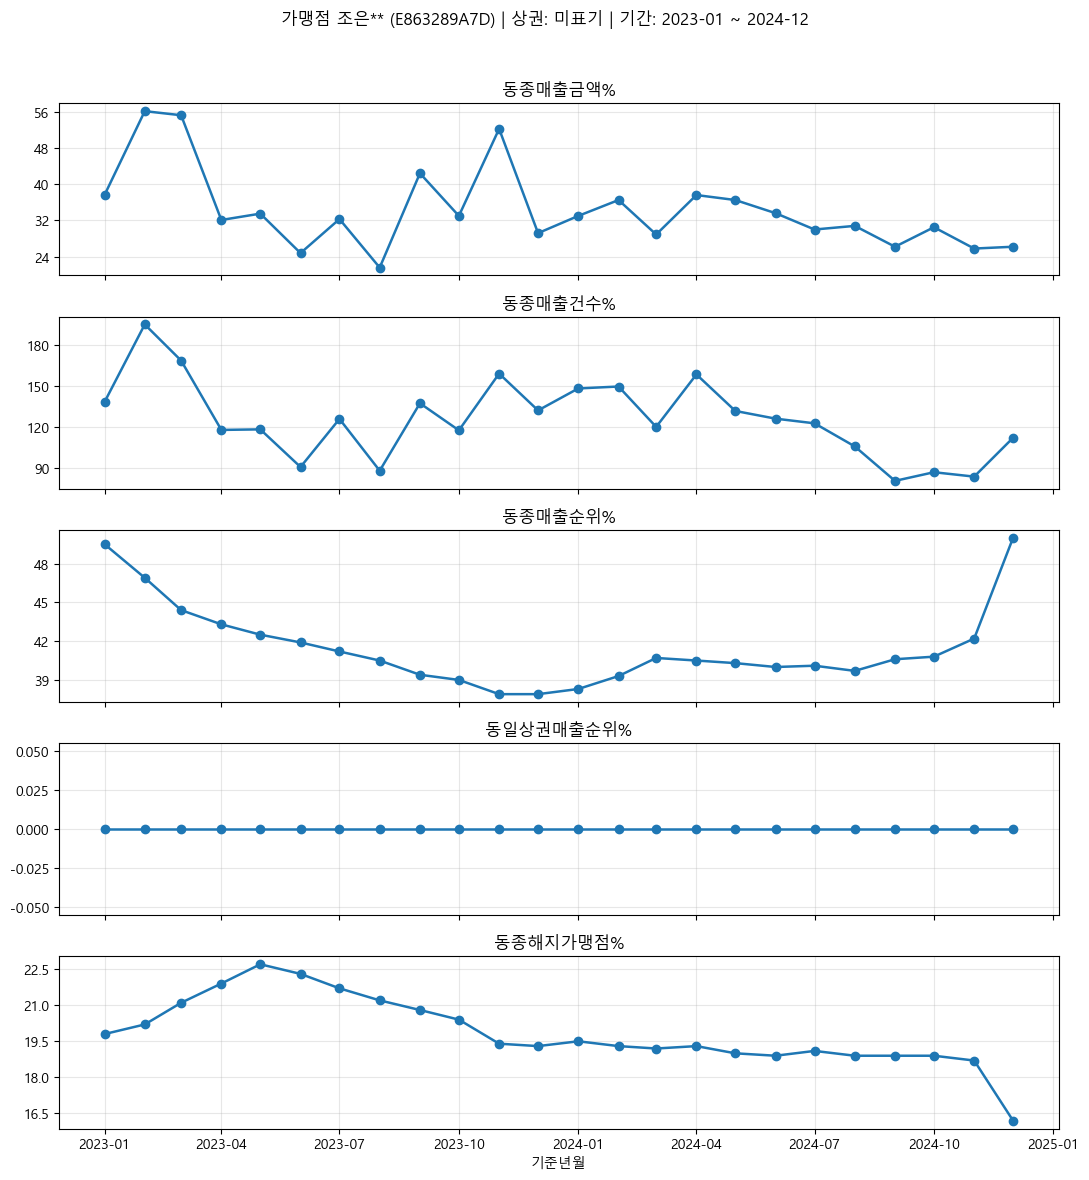

Saved: export\store_report_E863289A7D_202301_202412.png


,코드,가맹점명,상권,기준년월,기준년월_dt,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%
78355,E863289A7D,조은**,미표기,202403,2024-03-01,28.9,120.1,40.7,0.0,19.2
78356,E863289A7D,조은**,미표기,202404,2024-04-01,37.6,158.3,40.5,0.0,19.3
78357,E863289A7D,조은**,미표기,202405,2024-05-01,36.5,131.7,40.3,0.0,19.0
78358,E863289A7D,조은**,미표기,202406,2024-06-01,33.6,126.1,40.0,0.0,18.9
78359,E863289A7D,조은**,미표기,202407,2024-07-01,30.0,122.7,40.1,0.0,19.1
78360,E863289A7D,조은**,미표기,202408,2024-08-01,30.8,105.9,39.7,0.0,18.9
78361,E863289A7D,조은**,미표기,202409,2024-09-01,26.2,80.8,40.6,0.0,18.9
78362,E863289A7D,조은**,미표기,202410,2024-10-01,30.5,87.1,40.8,0.0,18.9
78363,E863289A7D,조은**,미표기,202411,2024-11-01,25.8,83.9,42.2,0.0,18.7
78364,E863289A7D,조은**,미표기,202412,2024-12-01,26.2,112.2,50.0,0.0,16.2


In [20]:
# 예시 실행: 가맹점 코드 입력 후 24개월 리포트 생성 및 저장
# 사용법: 아래 store_code에 원하는 코드를 넣고 실행하세요.
store_code = 'E863289A7D'  # 예시 코드
window_df = generate_store_report(store_code, months=24, save=True, outdir='export')

# window_df가 None이 아니면 생성된 데이터 확인
if window_df is not None:
    display(window_df[['코드','가맹점명','상권','기준년월','기준년월_dt','동종매출금액%','동종매출건수%','동종매출순위%','동일상권매출순위%','동종해지가맹점%']].tail(10))



In [ ]:
# 상권 CSV 파일에서 필요한 열들을 읽어서 현재 df에 매핑
상권_df = pd.read_csv("dataset/상권.csv", encoding="cp949")

# 필요한 열들만 선택 (ENCODED_MCT, TRDAR_CD_N, SIGNGU_CD_, ADSTRD_CD_)
상권_매핑 = 상권_df[['ENCODED_MCT', 'TRDAR_CD_N', 'SIGNGU_CD_', 'ADSTRD_CD_']].copy()

# ENCODED_MCT를 문자열로 변환 (df의 코드와 타입 맞추기)
상권_매핑['ENCODED_MCT'] = 상권_매핑['ENCODED_MCT'].astype(str)

print("상권 매핑 데이터 형태:", 상권_매핑.shape)
print("상권 매핑 데이터 샘플:")
print(상권_매핑.head())


In [ ]:
# 현재 df와 상권 매핑 데이터를 ENCODED_MCT(코드) 기준으로 병합
df_merged = df.merge(상권_매핑, left_on='코드', right_on='ENCODED_MCT', how='left')

# ENCODED_MCT 열은 중복이므로 제거
df_merged = df_merged.drop('ENCODED_MCT', axis=1)

# 새로운 열들의 이름을 더 명확하게 변경
df_merged = df_merged.rename(columns={
    'TRDAR_CD_N': '상권코드',
    'SIGNGU_CD_': '시군구코드', 
    'ADSTRD_CD_': '행정동코드'
})

print("병합 후 데이터 형태:", df_merged.shape)
print("새로 추가된 열들:")
print(df_merged[['코드', '상권코드', '시군구코드', '행정동코드']].head(10))


In [ ]:
# 매핑 결과 확인
print("매핑 성공률:")
print(f"- 상권코드 매핑 성공: {df_merged['상권코드'].notna().sum()} / {len(df_merged)} ({df_merged['상권코드'].notna().mean()*100:.1f}%)")
print(f"- 시군구코드 매핑 성공: {df_merged['시군구코드'].notna().sum()} / {len(df_merged)} ({df_merged['시군구코드'].notna().mean()*100:.1f}%)")
print(f"- 행정동코드 매핑 성공: {df_merged['행정동코드'].notna().sum()} / {len(df_merged)} ({df_merged['행정동코드'].notna().mean()*100:.1f}%)")

print("\n새로 추가된 열들의 고유값 개수:")
print(f"- 상권코드: {df_merged['상권코드'].nunique()}개")
print(f"- 시군구코드: {df_merged['시군구코드'].nunique()}개") 
print(f"- 행정동코드: {df_merged['행정동코드'].nunique()}개")

# df를 업데이트된 버전으로 교체
df = df_merged.copy()
print(f"\n최종 df 형태: {df.shape}")
